<a href="https://colab.research.google.com/github/sakshi685/Neural-Network/blob/main/Assignment01_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.**The Role of Weights in a Neuron**

In an artificial neural network, a neuron receives multiple inputs. A weight ($w$) acts as a scalar multiplier for each input, representing the strength or "importance" of that connection.Function: It determines how much influence a specific input feature has on the output. A high weight means the input strongly affects the neuron's output; a weight of zero means the input is ignored.Learning: During training, the model uses an optimization algorithm (like Gradient Descent) to adjust these weights to minimize the prediction error.If $x_1, x_2, \dots, x_n$ are inputs and $w_1, w_2, \dots, w_n$ are weights, the input to the neuron (before activation) is calculated as:$$z = \sum_{i=1}^{n} (x_i \cdot w_i) + b$$Where $b$ is the bias.

**2.What is an Activation Function?**

An activation function introduces non-linearity into the output of a neuron.

The Problem: Without an activation function, a neural network, no matter how many layers it has, would behave just like a simple linear regression model.

The Solution: It decides whether a neuron should be "activated" or not. By applying non-linear functions (like ReLU, Sigmoid, or Tanh), the model can learn and represent complex patterns, such as curved boundaries or non-linear relationships in data.

**3.Probability Distribution in Machine Learning**
In a neural network classification task, the model does not usually output a hard class label (e.g., "Cat"). Instead, it outputs a raw numerical vector called logits.Neural Context: We apply a normalization function, typically Softmax, to the output layer to convert these logits into a probability distribution.The Distribution: This output is a vector where every value is between $0$ and $1$, and the sum of all elements equals $1$. Each value represents the model's confidence level for that specific class. For example, an output of $[0.9, 0.05, 0.05]$ indicates the model is 90% confident the input belongs to the first class.


**4.The Gradient in Optimization**

In the context of neural networks, the gradient is the vector of partial derivatives of the Loss Function ($L$) with respect to all the weights and biases ($\theta$) in the network.Neural Context: It indicates the direction and magnitude of the steepest ascent of the error surface. To minimize the error, we perform Gradient Descent by moving in the opposite direction of the gradient:$$\theta_{new} = \theta_{old} - \eta \nabla L(\theta)$$where $\eta$ is the learning rate. This process is the core engine of training, where the network "learns" by adjusting its weights based on the computed gradient of the loss.

Epoch [10/100], Loss: 0.5913
Epoch [20/100], Loss: 0.5058
Epoch [30/100], Loss: 0.4490
Epoch [40/100], Loss: 0.4086
Epoch [50/100], Loss: 0.3782
Epoch [60/100], Loss: 0.3544
Epoch [70/100], Loss: 0.3352
Epoch [80/100], Loss: 0.3193
Epoch [90/100], Loss: 0.3058
Epoch [100/100], Loss: 0.2942


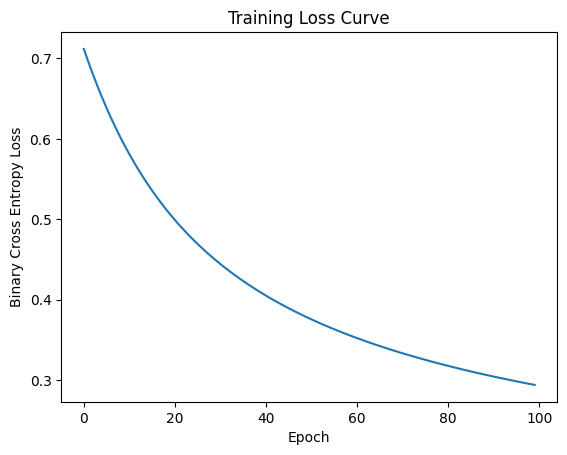

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Dataset Generation
# We define a simple linearly separable problem:
# If x1 + x2 > 0, label is 1; otherwise 0.
torch.manual_seed(42) # For reproducibility
X = torch.randn(100, 2)
y = (X[:, 0] + X[:, 1] > 0).float().view(-1, 1)

# 2. Model Definition
class LogisticRegression(nn.Module):
    """
    A single-layer perceptron acting as a Logistic Regression model.
    """
    def __init__(self):
        super(LogisticRegression, self).__init__()
        # nn.Linear represents: z = w*x + b
        self.linear = nn.Linear(2, 1)
        # nn.Sigmoid squashes the output into a probability (0 to 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        Computes the forward pass:
        1. Linear transformation (weighted sum)
        2. Non-linear activation (Sigmoid)
        """
        return self.sigmoid(self.linear(x))

model = LogisticRegression()

# 3. Optimization Setup
# Binary Cross Entropy (BCE) measures the distance between the
# predicted probability and the true label (0 or 1).
criterion = nn.BCELoss()
# Stochastic Gradient Descent (SGD) updates the weights based on the gradient.
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 4. Training Loop with History Tracking
loss_history = []
epochs = 100

for epoch in range(epochs):
    # A. Forward Pass: Calculate prediction
    y_pred = model(X)

    # B. Compute Loss
    loss = criterion(y_pred, y)
    loss_history.append(loss.item())

    # C. Backward Pass (Backpropagation)
    optimizer.zero_grad() # Clear old gradients
    loss.backward()       # Compute gradients of loss w.r.t weights
    optimizer.step()      # Update weights (Gradient Descent step)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# 5. Visualization
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.show()